In [11]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


**1. Data Understanding**

In [12]:
import pandas as pd

# Load dataset (example: IMDb dataset CSV)
df = pd.read_csv("IMDB Dataset.csv")

# View data
print(df.head())

# Shape
print("Shape:", df.shape)

# Class distribution
print(df['sentiment'].value_counts())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


**2. NLP Preprocessing**

In [13]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [14]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove special characters & punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenization
    tokens = text.split()

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]

    return " ".join(tokens)

In [15]:
df['clean_text'] = df['review'].apply(preprocess_text)

print(df[['review', 'clean_text']].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                          clean_text  
0  one review mention watch oz episod youll hook ...  
1  wonder littl product br br film techniqu unass...  
2  thought wonder way spend time hot summer weeke...  
3  basic there famili littl boy jake think there ...  
4  petter mattei love time money visual stun film...  


**3. Feature Engineering**

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['clean_text']).toarray()

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text']).toarray()

In [19]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(df['sentiment'])  # positive=1, negative=0

**4. Train-Test Split**

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

**5. Model Building**

In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [22]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

**6. Model Evaluation**

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_test, y_pred, model_name):
    print(f"\n{model_name} Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_nb, "Naive Bayes")
evaluate(y_test, y_pred_dt, "Decision Tree")


Logistic Regression Performance:
Accuracy: 0.8841
Precision: 0.873795761078998
Recall: 0.8999801547926176
F1 Score: 0.8866946915632027

Naive Bayes Performance:
Accuracy: 0.8458
Precision: 0.8431795878312071
Recall: 0.8525501091486406
F1 Score: 0.8478389579632919

Decision Tree Performance:
Accuracy: 0.7092
Precision: 0.7141708542713567
Recall: 0.7051002182972812
F1 Score: 0.7096065508288396


**7. Comparison & Insight**
**Best Model**
Logistic Regression performed best due to:
1. Works well with high-dimensional sparse data
2. Handles TF-IDF features effectively

**Best Feature Engineering**
TF-IDF > BoW
Reason:

TF-IDF reduces importance of frequent but less meaningful words

**Best Preprocessing Steps**
1. Stopword removal improved performance
2. Stemming reduced vocabulary size
3. Removing noise improved accuracy

### Trade-offs

| Model | Advantage | Disadvantage |
|-------|----------|-------------|
| Logistic Regression | High accuracy | Slightly slower |
| Naive Bayes | Fast | Assumes independence |
| Decision Tree | Easy to interpret | Overfitting |

**Confusion Matrix**

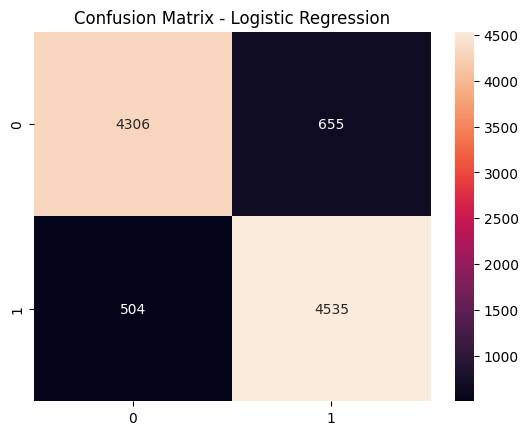

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Final Pipeline Function**

In [26]:
def predict_sentiment(text):
    processed = preprocess_text(text)
    vector = tfidf.transform([processed]).toarray()
    prediction = lr.predict(vector)

    return "Positive" if prediction[0] == 1 else "Negative"


# Test
print(predict_sentiment("This movie was amazing!"))

Positive
